In [43]:
from google.colab import files
uploaded = files.upload()

Saving titanic.csv to titanic (2).csv


In [101]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import plot_tree
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix

In [72]:
titanic = pd.read_csv("titanic.csv")

In [73]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1310 entries, 0 to 1309
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1309 non-null   float64
 1   survived   1309 non-null   float64
 2   name       1309 non-null   object 
 3   sex        1309 non-null   object 
 4   age        1046 non-null   float64
 5   sibsp      1309 non-null   float64
 6   parch      1309 non-null   float64
 7   ticket     1309 non-null   object 
 8   fare       1308 non-null   float64
 9   cabin      295 non-null    object 
 10  embarked   1307 non-null   object 
 11  boat       486 non-null    object 
 12  body       121 non-null    float64
 13  home.dest  745 non-null    object 
dtypes: float64(7), object(7)
memory usage: 143.4+ KB


In [74]:
titanic.describe(include='all')

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
count,1309.000000,1309.000000,1309,1309,1046.000000,1309.000000,1309.000000,1309,1308.000000,295,1307,486,121.000000,745
unique,NaN,NaN,1307,2,NaN,NaN,NaN,929,NaN,186,3,27,NaN,369
top,NaN,NaN,"Kelly, Mr. James",male,NaN,NaN,NaN,CA. 2343,NaN,C23 C25 C27,S,13,NaN,"New York, NY"
freq,NaN,NaN,2,843,NaN,NaN,NaN,11,NaN,6,914,39,NaN,64
mean,2.294882,0.381971,NaN,NaN,29.881135,0.498854,0.385027,NaN,33.295479,NaN,NaN,NaN,160.809917,NaN
std,0.837836,0.486055,NaN,NaN,14.413500,1.041658,0.865560,NaN,51.758668,NaN,NaN,NaN,97.696922,NaN
min,1.000000,0.000000,NaN,NaN,0.166700,0.000000,0.000000,NaN,0.000000,NaN,NaN,NaN,1.000000,NaN
25%,2.000000,0.000000,NaN,NaN,21.000000,0.000000,0.000000,NaN,7.895800,NaN,NaN,NaN,72.000000,NaN
50%,3.000000,0.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN,NaN,155.000000,NaN
75%,3.000000,1.000000,NaN,NaN,39.000000,1.000000,0.000000,NaN,31.275000,NaN,NaN,NaN,256.000000,NaN


In [75]:
#Bo cac bien so co gia tri NaN qua nhieu hoac khong anh huong toi kha nang song sot
titanic = titanic.drop(columns=['name','cabin', 'boat', 'body', 'home.dest','ticket'])

In [76]:
titanic.describe(include='all')

,pclass,survived,sex,age,sibsp,parch,fare,embarked
count,1309.000000,1309.000000,1309,1046.000000,1309.000000,1309.000000,1308.000000,1307
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S
freq,NaN,NaN,843,NaN,NaN,NaN,NaN,914
mean,2.294882,0.381971,NaN,29.881135,0.498854,0.385027,33.295479,NaN
std,0.837836,0.486055,NaN,14.413500,1.041658,0.865560,51.758668,NaN
min,1.000000,0.000000,NaN,0.166700,0.000000,0.000000,0.000000,NaN
25%,2.000000,0.000000,NaN,21.000000,0.000000,0.000000,7.895800,NaN
50%,3.000000,0.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN
75%,3.000000,1.000000,NaN,39.000000,1.000000,0.000000,31.275000,NaN


In [77]:
# Loại bỏ các hàng có giá trị NaN
titanic = titanic.dropna()

In [78]:
label_encoder = LabelEncoder()
# Chuyển cột 'sex' thành giá trị số (male = 1, female = 0)
titanic['sex'] = label_encoder.fit_transform(titanic['sex'])
print(titanic.head())

   pclass  survived  sex      age  sibsp  parch      fare embarked
0     1.0       1.0    0  29.0000    0.0    0.0  211.3375        S
1     1.0       1.0    1   0.9167    1.0    2.0  151.5500        S
2     1.0       0.0    0   2.0000    1.0    2.0  151.5500        S
3     1.0       0.0    1  30.0000    1.0    2.0  151.5500        S
4     1.0       0.0    0  25.0000    1.0    2.0  151.5500        S


In [79]:
label_encoder_embarked = LabelEncoder()

# Chuyển cột 'embarked' thành giá trị số
titanic['embarked'] = label_encoder_embarked.fit_transform(titanic['embarked'])

# Kiểm tra lại dữ liệu sau khi mã hóa
print(titanic.head())

   pclass  survived  sex      age  sibsp  parch      fare  embarked
0     1.0       1.0    0  29.0000    0.0    0.0  211.3375         2
1     1.0       1.0    1   0.9167    1.0    2.0  151.5500         2
2     1.0       0.0    0   2.0000    1.0    2.0  151.5500         2
3     1.0       0.0    1  30.0000    1.0    2.0  151.5500         2
4     1.0       0.0    0  25.0000    1.0    2.0  151.5500         2


In [80]:
# Chuyển cột 'survived' thành kiểu dữ liệu category (yếu tố nhãn cho mô hình)
titanic['survived'] = titanic['survived'].astype('category')

# Phân chia dữ liệu thành tập huấn luyện (training set) và tập kiểm tra (test set)
X = titanic.drop('survived', axis=1)  # Các đặc trưng
y = titanic['survived']  # Nhãn (target variable)

# Phân chia dữ liệu: 75% huấn luyện và 25% kiểm tra
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=2000)

# Kiểm tra thông tin về dữ liệu phân chia
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Training set size: 782 samples
Test set size: 261 samples


In [92]:
# Mô hình cây quyết định với min_samples_leaf =25
tree_model = DecisionTreeClassifier(min_samples_leaf=25, random_state=2000)
tree_model.fit(X_train, y_train)

# Dự đoán trên tập kiểm tra
y_pred = tree_model.predict(X_test)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Đánh giá độ chính xác
accuracy = (conf_matrix[0,0] + conf_matrix[1,1]) / conf_matrix.sum()
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.82


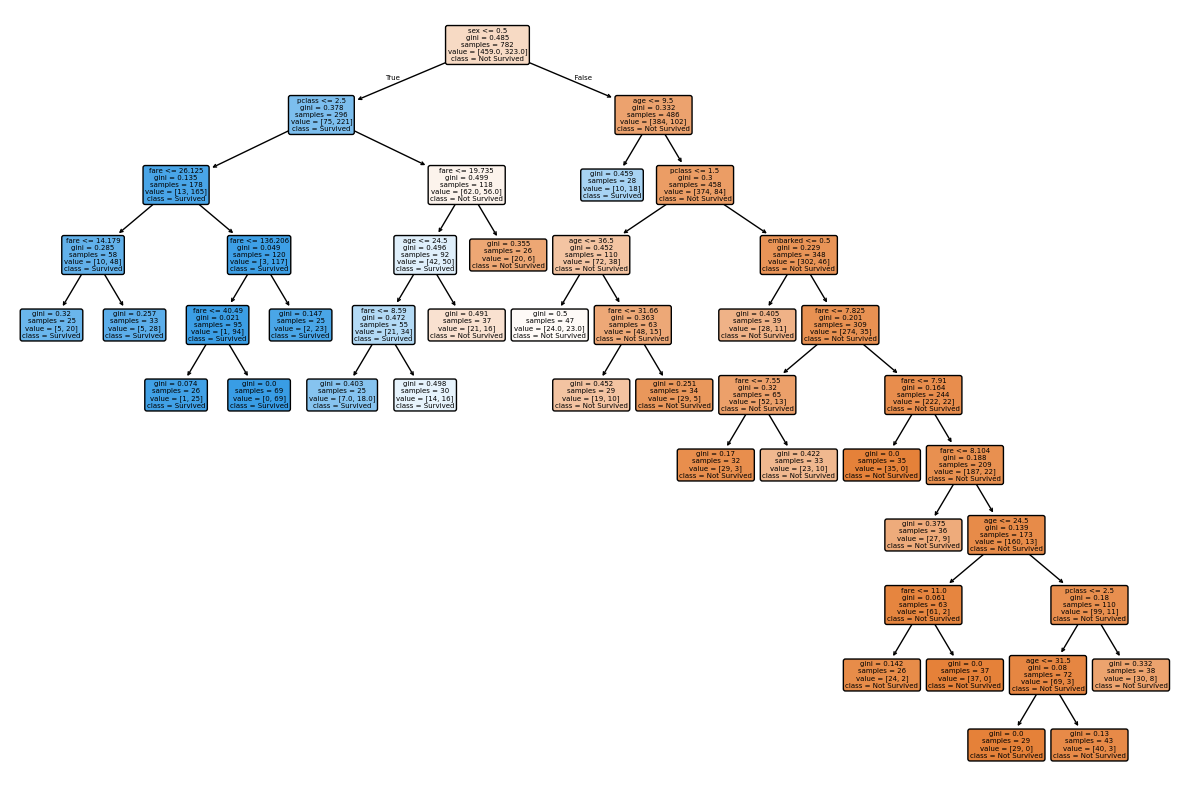

In [87]:

# Vẽ cây quyết định
plt.figure(figsize=(15,10))
plot_tree(tree_model,
          feature_names=X_train.columns,
          class_names=['Not Survived', 'Survived'],
          filled=True, rounded=True)
plt.show()  # Hiển thị cây quyết định

In [99]:
#Model 2 :Su dung cross-validation de lua chon tham so cp cua mo hinh
# Thiết lập giá trị tham số ccp_alpha
param_grid = {'ccp_alpha': [i * 0.001 for i in range(1, 1001)]}

In [96]:
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=2000), param_grid, cv=10)
grid_search.fit(X_train, y_train)
print("Best ccp_alpha:", grid_search.best_params_)

Best ccp_alpha: {'ccp_alpha': 0.009000000000000001}


In [97]:
# Tạo mô hình cây quyết định với tham số tối ưu từ GridSearch
best_tree_model = grid_search.best_estimator_

# Dự đoán trên tập kiểm tra
y_pred_best = best_tree_model.predict(X_test)

# Confusion Matrix
conf_matrix_best = confusion_matrix(y_test, y_pred_best)
print(conf_matrix_best)

# Đánh giá độ chính xác
accuracy_best = accuracy_score(y_test, y_pred_best)
print(f"Accuracy with best ccp_alpha: {accuracy_best:.2f}")

[[154   5]
 [ 43  59]]
Accuracy with best ccp_alpha: 0.82


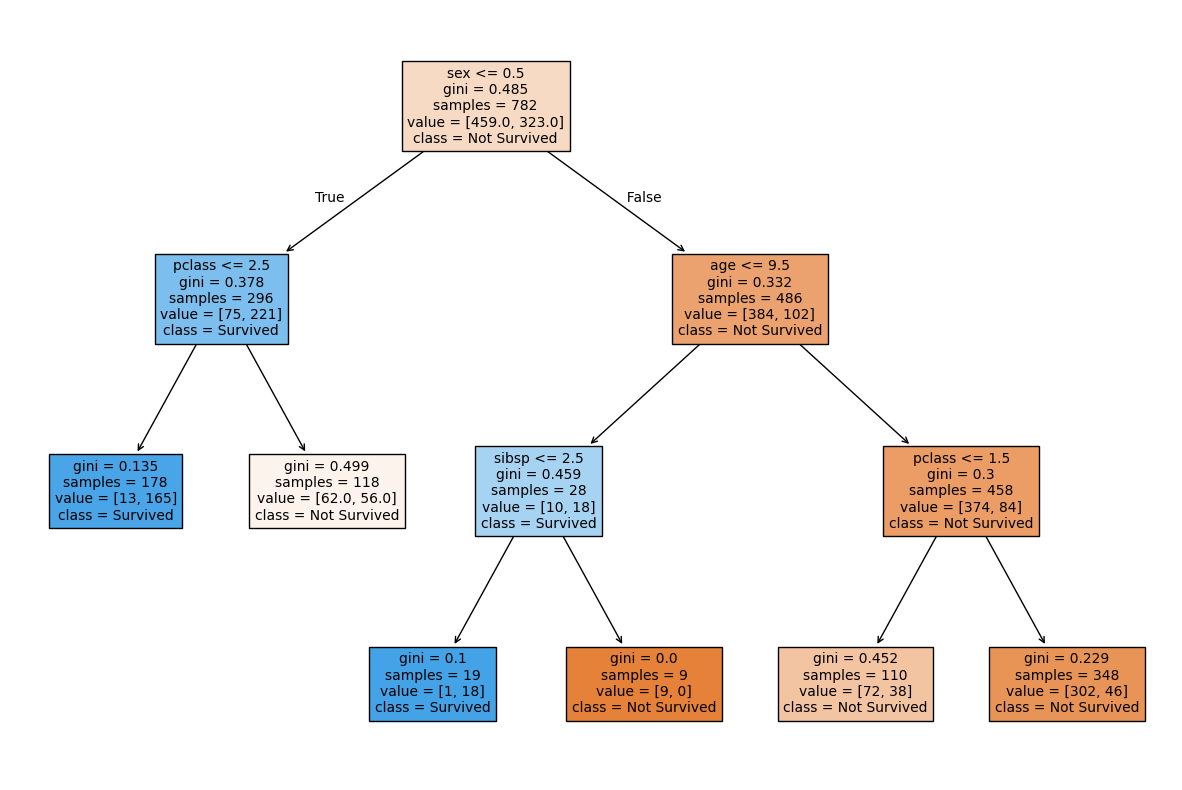

In [98]:
# Vẽ cây quyết định
plt.figure(figsize=(15, 10))
plot_tree(best_tree_model, filled=True, feature_names=X.columns, class_names=['Not Survived', 'Survived'], fontsize=10)
plt.show()

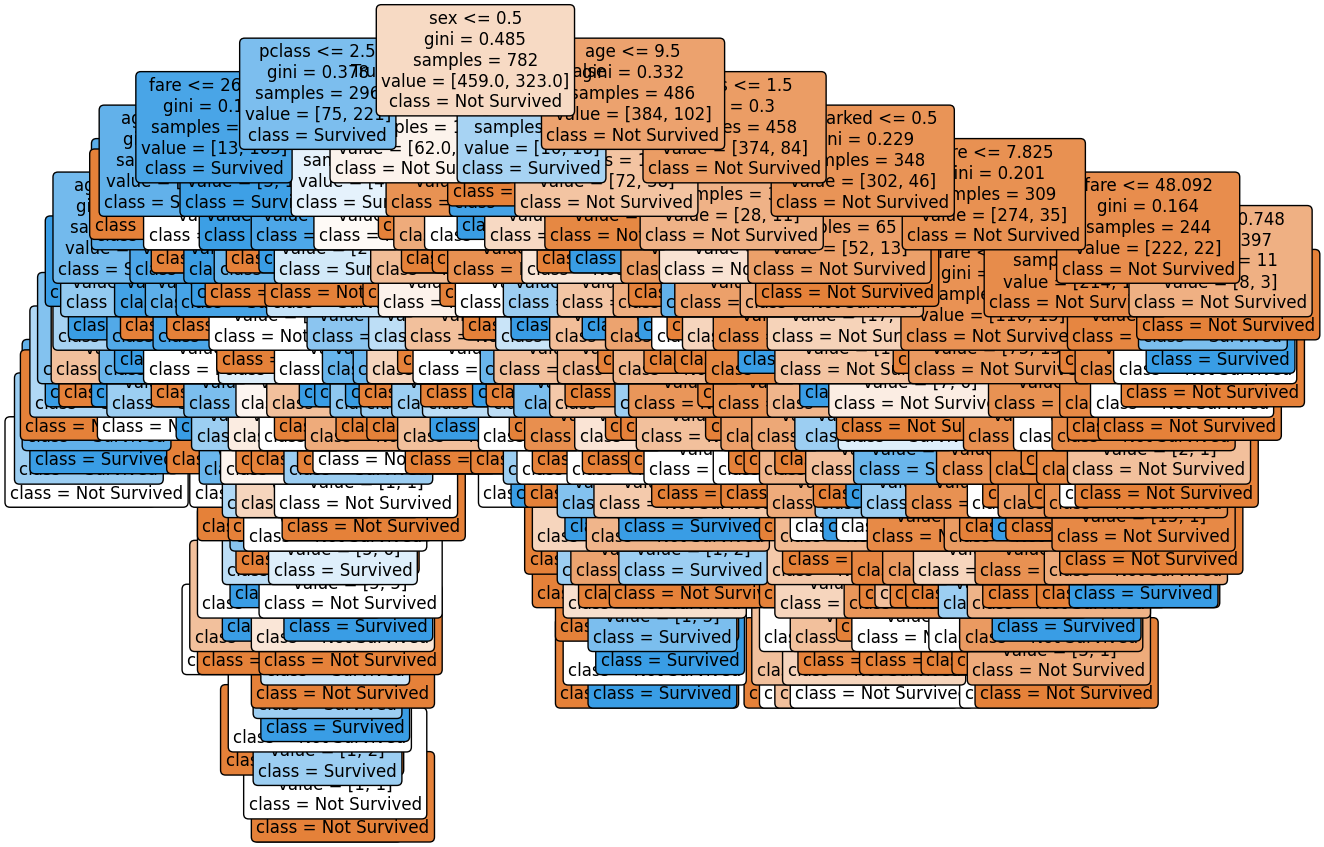

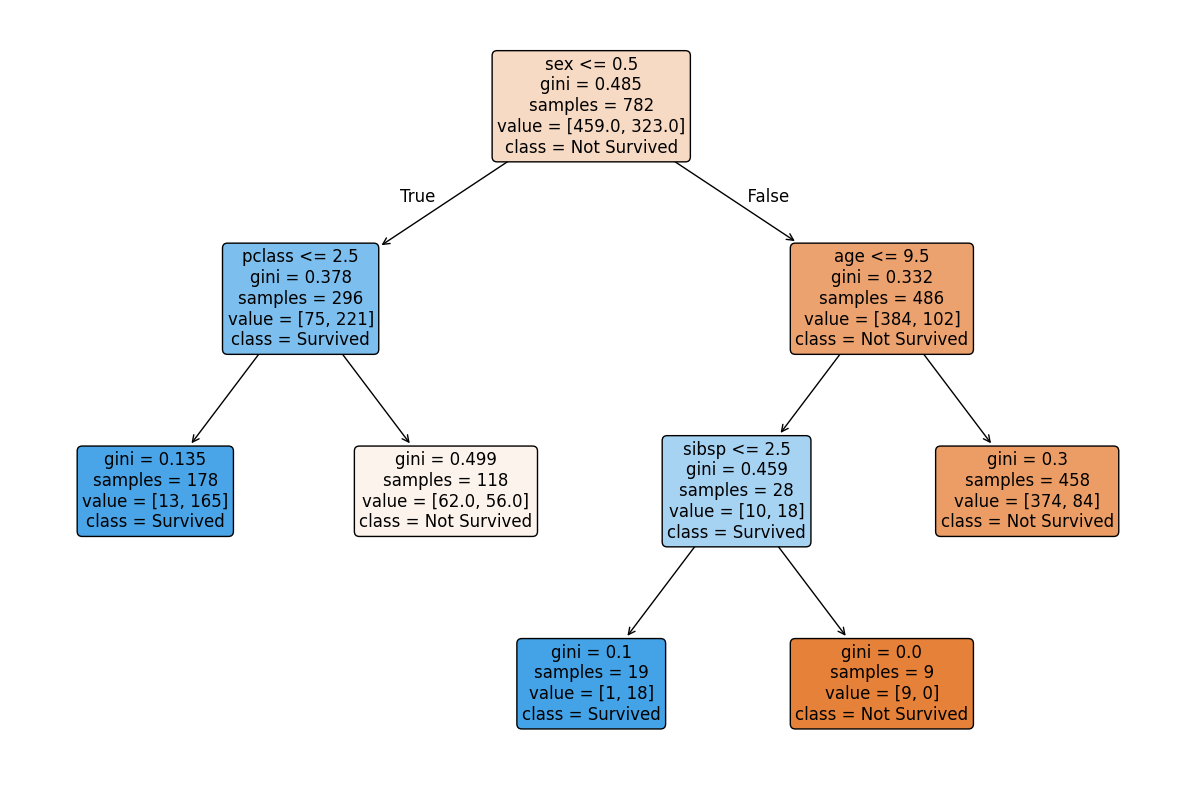

Accuracy of pruned model: 0.82


In [100]:
# Xây dựng mô hình cây quyết định phức tạp
tree_model_complex = DecisionTreeClassifier(random_state=2000)
tree_model_complex.fit(X_train, y_train)

# Vẽ cây quyết định
plt.figure(figsize=(15,10))
plot_tree(tree_model_complex, filled=True, feature_names=X_train.columns, class_names=['Not Survived', 'Survived'], rounded=True, fontsize=12)
plt.show()

# Pruning cây quyết định bằng cách sử dụng giá trị 'ccp_alpha' đã tính toán từ cross-validation
tree_model_pruned = DecisionTreeClassifier(random_state=2000, ccp_alpha=0.013)
tree_model_pruned.fit(X_train, y_train)

# Vẽ cây quyết định đã được pruning
plt.figure(figsize=(15,10))
plot_tree(tree_model_pruned, filled=True, feature_names=X_train.columns, class_names=['Not Survived', 'Survived'], rounded=True, fontsize=12)
plt.show()

# Dự đoán trên tập kiểm tra
y_pred_pruned = tree_model_pruned.predict(X_test)

# Tính Confusion Matrix
conf_matrix_pruned = confusion_matrix(y_test, y_pred_pruned)

# Đánh giá độ chính xác
accuracy_pruned = (conf_matrix_pruned[0,0] + conf_matrix_pruned[1,1]) / conf_matrix_pruned.sum()
print(f"Accuracy of pruned model: {accuracy_pruned:.2f}")

In [102]:
# Xây dựng mô hình Random Forest
forest_model = RandomForestClassifier(random_state=2000)
forest_model.fit(X_train, y_train)

# Dự đoán trên tập kiểm tra
y_pred_forest = forest_model.predict(X_test)

# Tính Confusion Matrix
conf_matrix_forest = confusion_matrix(y_test, y_pred_forest)

# Đánh giá độ chính xác
accuracy_forest = (conf_matrix_forest[0,0] + conf_matrix_forest[1,1]) / conf_matrix_forest.sum()
print(f"Accuracy of Random Forest model: {accuracy_forest:.2f}")

Accuracy of Random Forest model: 0.78


In [103]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

In [104]:
# Khởi tạo mô hình Gradient Boosting
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

# Huấn luyện mô hình
gb_model.fit(X_train, y_train)

# Dự đoán trên tập kiểm tra
y_pred = gb_model.predict(X_test)

# Đánh giá độ chính xác
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

Accuracy: 0.84
Confusion Matrix:
[[148  11]
 [ 32  70]]
